Desarrollado por: Nancy Borges
Proyecto: Modelo de Scoring Crediticio mediante Regresión Logística
Contexto: El objetivo de este análisis es predecir el riesgo crediticio de los clientes de una entidad financiera. Utilizaremos el dataset German Credit para clasificar a los solicitantes en categorías de riesgo "Bueno" o "Malo"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

datos_credito = pd.read_csv(r'C:\Users\Outlet\Desktop\Nueva carpeta (2)\germanCredit.csv')
datos_credito.head()

,clientid,ingresos,edad,prestamo,LTI,default10an
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1


Exploración de Dimensiones

In [5]:
datos_credito.shape

(2000, 6)

Análisis Estadístico Descriptivo

In [7]:
datos_credito.describe()

,clientid,ingresos,edad,prestamo,LTI,default10an
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.927143,4444.369695,0.098403,0.141500
std,577.494589,14326.327119,13.262450,3045.410024,0.057620,0.348624
min,1.000000,20014.489470,18.055189,1.377630,0.000049,0.000000
25%,500.750000,32796.459717,29.062492,1939.708847,0.047903,0.000000
50%,1000.500000,45789.117313,41.382673,3974.719419,0.099437,0.000000
75%,1500.250000,57791.281668,52.596993,6432.410625,0.147585,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,0.199938,1.000000


Estructura y Tipos de Datos

In [8]:
datos_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   clientid     2000 non-null   int64  
 1   ingresos     2000 non-null   float64
 2   edad         2000 non-null   float64
 3   prestamo     2000 non-null   float64
 4   LTI          2000 non-null   float64
 5   default10an  2000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 93.9 KB


Análisis Exploratorio de Datos (EDA): Variables Numéricas
En esta sección se analizan las distribuciones y la dispersión de las variables clave del dataset (Ingresos, Edad, Préstamo, LTI, entre otras). El objetivo es identificar sesgos, valores atípicos y entender la naturaleza de los datos.

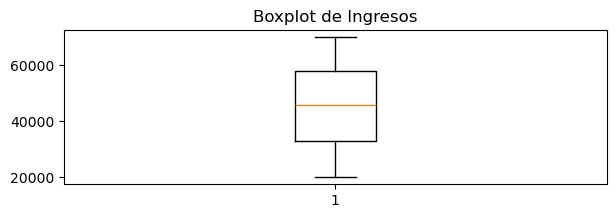

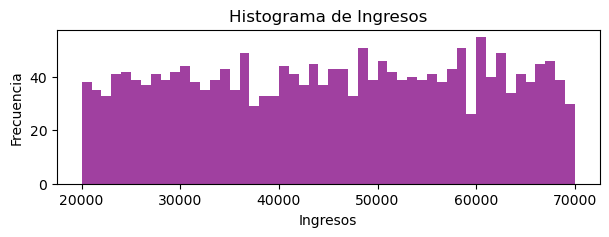

In [11]:
#Creación del boxplot
plt.figure(figsize=(7,2))
plt.boxplot(datos_credito['ingresos'])
plt.title('Boxplot de Ingresos')
plt.show()

#Creación del histograma
plt.figure(figsize=(7,2))
plt.hist(x=datos_credito.ingresos,bins=50,alpha = 0.75, facecolor='purple')
plt.title('Histograma de Ingresos')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()
            


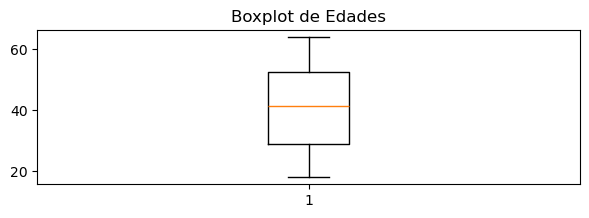

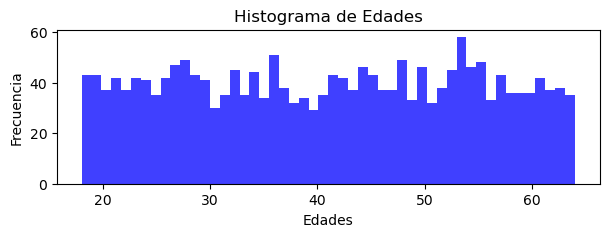

In [17]:
#Creación del boxplot
plt.figure(figsize=(7,2))
plt.boxplot(datos_credito['edad'])
plt.title('Boxplot de Edades')
plt.show()

#Creación del histograma
plt.figure(figsize=(7,2))
plt.hist(x=datos_credito.edad,bins=50,alpha = 0.75, facecolor='blue')
plt.title('Histograma de Edades')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')
plt.show()
          

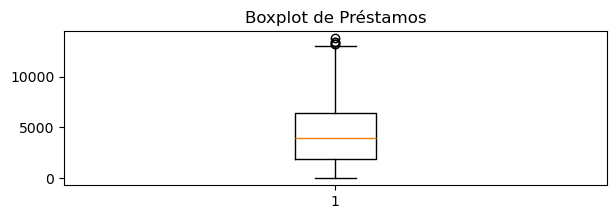

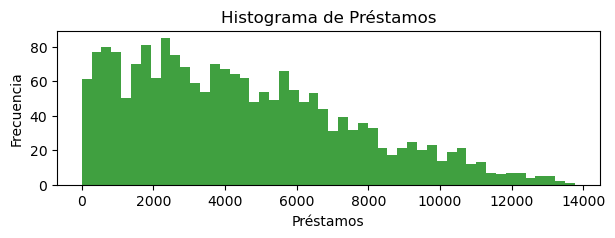

In [19]:
#Creación del boxplot
plt.figure(figsize=(7,2))
plt.boxplot(datos_credito['prestamo'])
plt.title('Boxplot de Préstamos')
plt.show()

#Creación del histograma
plt.figure(figsize=(7,2))
plt.hist(x=datos_credito.prestamo,bins=50,alpha = 0.75, facecolor='green')
plt.title('Histograma de Préstamos')
plt.xlabel('Préstamos')
plt.ylabel('Frecuencia')
plt.show()
          

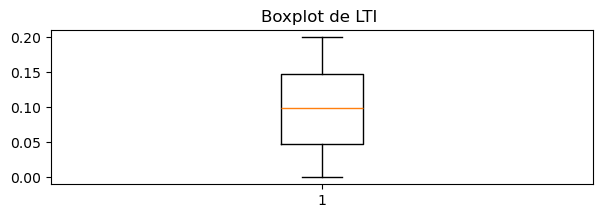

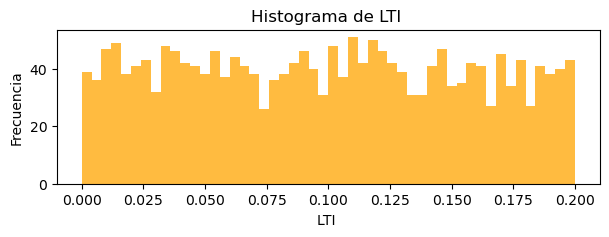

In [16]:
#Creación del boxplot
plt.figure(figsize=(7,2))
plt.boxplot(datos_credito['LTI'])
plt.title('Boxplot de LTI ')
plt.show()

#Creación del histograma
plt.figure(figsize=(7,2))
plt.hist(x=datos_credito.LTI ,bins=50,alpha = 0.75, facecolor='orange')
plt.title('Histograma de LTI ')
plt.xlabel('LTI ')
plt.ylabel('Frecuencia')
plt.show()
          

Análisis de la Variable Objetivo: Balance de Clases
Para que un modelo de Machine Learning sea efectivo, es fundamental analizar la proporción de las categorías que queremos predecir. En este caso, evaluamos la relación entre clientes que cumplieron con su préstamo frente a aquellos que entraron en default.

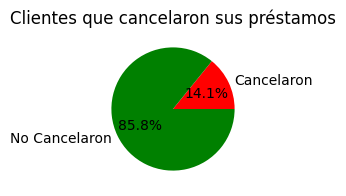

In [3]:
#Creación de los dataframe filtrados
clientes_cancelados = datos_credito[datos_credito['default10an']==1]
clientes_no_cancelados = datos_credito[datos_credito['default10an']==0]

#Creación de array con cantidad de clientes cancelos y de clientes no cancelados
valores=[clientes_cancelados.shape[0],clientes_no_cancelados.shape[0]]
etiquetas = ['Cancelaron','No Cancelaron']
colores = ['red','green']

#Creación del diagrama de pastel con los valores
plt.figure(figsize=(7,2))
plt.title('Clientes que cancelaron sus préstamos')
plt.pie(valores, labels=etiquetas, autopct = '%1.1f%%', colors= colores)
plt.show()



Análisis de Multicolinealidad (Matriz de Correlación)
Calculamos los coeficientes de correlación de Pearson para identificar relaciones lineales entre las variables. 
Este análisis nos permite detectar si existen variables altamente correlacionadas que podrían estar aportando información redundante al modelo.

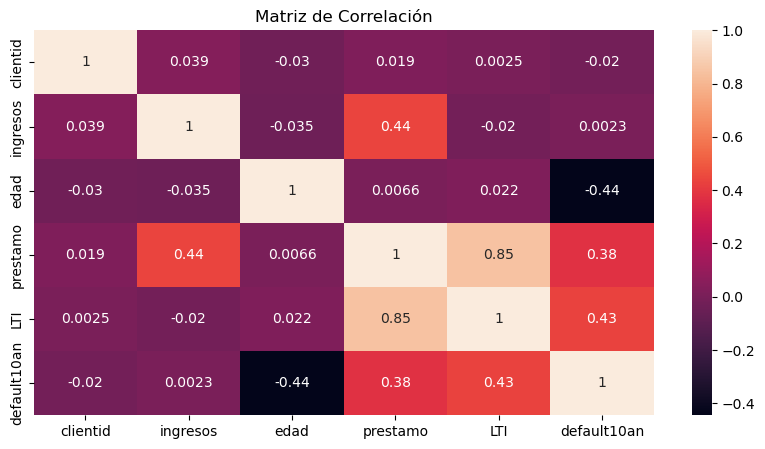

In [24]:
import seaborn as sns

#Creación matriz de correlación
correlation_mat= datos_credito.corr()
plt.figure(figsize=(10,5))
plt.title('Matriz de Correlación')
sns.heatmap(correlation_mat, annot= True)
plt.show()

Preprocesamiento: Limpieza y Selección de Variables
Para construir un modelo robusto, eliminamos las columnas de identificación (clientid) que no guardan relación con el comportamiento crediticio. Esto evita que el modelo aprenda sesgos basados en el orden de registro y se concentre exclusivamente en las variables financieras y demográficas.

In [8]:
#Selección de los datos, eliminamos la columna clientes
datos_limpios = datos_credito.drop('clientid',axis=1)
datos_limpios.head()

,ingresos,edad,prestamo,LTI,default10an
0,66155.925095,59.017015,8106.532131,0.122537,0
1,34415.153966,48.117153,6564.745018,0.190752,0
2,57317.170063,63.108049,8020.953296,0.139940,0
3,42709.534201,45.751972,6103.642260,0.142911,0
4,66952.688845,18.584336,8770.099235,0.130989,1


Tratamiento de Outliers (Método IQR)
Para asegurar la estabilidad del modelo, identificamos los valores atípicos en la variable prestamo. Utilizaremos el método del Rango Intercuartílico (IQR) para establecer un límite superior técnico. Los registros que superen este umbral serán analizados para evitar que sesguen la frontera de decisión de nuestra Regresión Logística.

In [9]:
#limpieza de datos, eliminamos valores atipicos en la columna prestamos
import numpy as np

#calculo de cuartiles
Q1 = np.percentile(datos_credito.prestamo,25)
Q3 = np.percentile(datos_credito.prestamo,75)

#calculo de distancia entre cuartiles
IQR = Q3-Q1

#calculo del valor maximo

maximo = Q3+1.5*IQR

#consulta de valores de cuartiles
print('Q1:'+ str(Q1))
print('Q3:'+ str(Q3))    

#consulta del valor maximo
print(' valor maximo:'+str(maximo))



Q1:1939.7088471558375
Q3:6432.41062462344
 valor maximo:13171.463290824842


Aplicación del Filtro de Outliers
Procedemos a filtrar el dataset para conservar únicamente aquellos registros que se encuentran dentro del rango estadístico aceptable. Esto garantiza que nuestro modelo de Regresión Logística no se vea influenciado por casos extremos que no representan el comportamiento general de la cartera de clientes.

In [33]:
datos_limpios = datos_credito[datos_credito.prestamo < maximo]
datos_limpios.head()

,clientid,ingresos,edad,prestamo,LTI,default10an
0,1,66155.925095,59.017015,8106.532131,0.122537,0
1,2,34415.153966,48.117153,6564.745018,0.190752,0
2,3,57317.170063,63.108049,8020.953296,0.139940,0
3,4,42709.534201,45.751972,6103.642260,0.142911,0
4,5,66952.688845,18.584336,8770.099235,0.130989,1


In [36]:
datos_limpios.shape

(1995, 6)

Validación Visual: Impacto de la Limpieza
Comparamos la distribución de la variable prestamo antes y después del tratamiento de outliers. El objetivo es confirmar que hemos eliminado los valores extremos, logrando un set de datos más estable para el modelado.

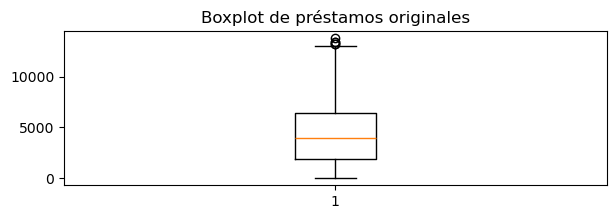

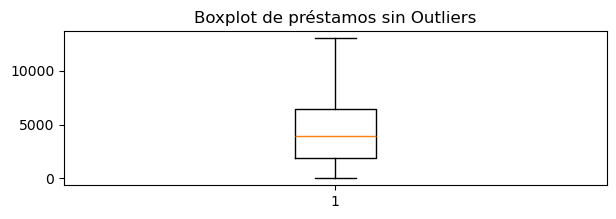

In [38]:
plt.figure(figsize=(7,2))
plt.boxplot(datos_credito.prestamo)
plt.title('Boxplot de préstamos originales')
plt.show()

plt.figure(figsize=(7,2))
plt.boxplot(datos_limpios.prestamo)
plt.title('Boxplot de préstamos sin Outliers')
plt.show()

In [5]:
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split



Renombrado de la Variable Objetivo
Cambiamos el nombre de la variable dependiente a pago_prestamo para facilitar la interpretación de los resultados. En este análisis, el valor 1 representa un incumplimiento o cancelación y el 0 representa un cumplimiento exitoso.

In [10]:
datos_limpios = datos_limpios.rename(columns={'default10an':'pago_prestamo'})
datos_limpios.head()
                                     

,ingresos,edad,prestamo,LTI,pago_prestamo
0,66155.925095,59.017015,8106.532131,0.122537,0
1,34415.153966,48.117153,6564.745018,0.190752,0
2,57317.170063,63.108049,8020.953296,0.139940,0
3,42709.534201,45.751972,6103.642260,0.142911,0
4,66952.688845,18.584336,8770.099235,0.130989,1


Construcción del Modelo de Regresión Logística
En esta etapa, dividimos nuestros datos en un conjunto de entrenamiento (80%) y uno de prueba (20%). Esto nos permite entrenar el algoritmo con datos conocidos y luego validar su precisión con datos que el modelo nunca ha visto.

Hemos configurado el modelo con un parámetro de regularización C=0.01 y el optimizador sag para asegurar una convergencia eficiente.

In [45]:
#select data for modeling
#variable predictora
X= np.array(datos_limpios.drop(['pago_prestamo','edad','prestamo'],axis=1))
y= datos_limpios['pago_prestamo'].values

#creamos el conjunto de datos de entrenamiento y testing

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

#nota: solucionadores disponible newton-cg, Lbfgs, Liblinear, sag, saga,defoult=Lbfgs

model = linear_model.LogisticRegression(C=0.01,solver='sag')
clf = model.fit(X_train, y_train)


#predecimos las etiquetas del conjunto de datos de prueba

LR1_pred_labels = clf.predict(X_test)

#imprimimos la intercepcion y la pendiente
print('Intercepcion (Beta 0):', clf.intercept_)
print('Pendiente (Beta 1):', clf.coef_)



Intercepcion (Beta 0): [-2.04502102e-06]
Pendiente (Beta 1): [[-4.73204832e-04 -2.92233375e-05  8.61839758e-07]]


Evaluación del Desempeño: Exactitud (Accuracy)
La métrica de Accuracy nos proporciona una visión general de la eficacia del modelo. Representa la proporción de predicciones correctas (tanto cumplimientos como incumplimientos) frente al total de casos evaluados en el set de testeo.

In [46]:
#obtenemos la precision del modelo
score = clf.score(X_test, y_test)
print('Accuracy Score:', score)


Accuracy Score: 0.8421052631578947


Análisis de Probabilidades de Incumplimiento
Más allá de la clasificación binaria (Paga / No Paga), generamos las probabilidades individuales para cada registro. Esto permite establecer umbrales de decisión personalizado. Por ejemplo, un banco podría ser más conservador y rechazar préstamos si la probabilidad de "pago" es menor al 70%.

In [47]:
#predecir probabilidades para cada etiqueta de clase de datos de prueba
probs=model.predict_proba(X_test)
print(y_test)

[1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


Entrenamiento del Modelo de Regresión Logística Final
Tras completar el Análisis Exploratorio y la limpieza de outliers, procedemos a entrenar el modelo de clasificación. En esta etapa definitiva, utilizamos el dataset procesado para que el algoritmo aprenda los patrones que distinguen a un cliente cumplidor de uno con riesgo de default.

In [11]:
#regresion logistica multinomial

#variable predictora
X= np.array(datos_limpios.drop(['pago_prestamo'],axis=1))

#variable a predecir
y = np.array(datos_limpios['pago_prestamo'])

#creamos el conjunto de datos de entrenamiento %80 y testing %20

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

# Usamos el parámetro por defecto o 'ovr' para problemas binarios
modelo = linear_model.LogisticRegression(solver='lbfgs', max_iter=1000)
modelo.fit(X_train, y_train)

# Verificamos la precisión
print(f"Precisión del modelo final: {modelo.score(X_test, y_test):.4f}")


Precisión del modelo final: 0.9525


Fase de Predicción y Validación
Una vez entrenado el modelo, procedemos a realizar las predicciones sobre el conjunto de datos de prueba (X_test). Este paso es crucial para verificar cómo se comporta el algoritmo ante datos nuevos y reales. El resultado es un vector de clasificaciones donde 1 indica riesgo de incumplimiento y 0 cumplimiento de pago.

In [54]:
#probar el modelo para predecir. Utilizando el conjunto de valores de testing: x_test

predicciones = modelo.predict(X_test)

print(predicciones)


[1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]


Validación de Resultados: Score de Exactitud
La métrica de Accuracy nos indica el porcentaje total de predicciones correctas. En un entorno de Scoring Crediticio, este valor nos da la confianza inicial necesaria para desplegar el modelo en un entorno de pruebas, asegurando que la mayoría de los perfiles de riesgo sean identificados correctamente.

In [55]:
accuracy_score(y_test,predicciones)

0.949874686716792

Matriz de Confusión: Evaluación de Aciertos y Errores
Mientras que el Accuracy nos da una idea general, la Matriz de Confusión nos permite desglosar el desempeño del modelo.

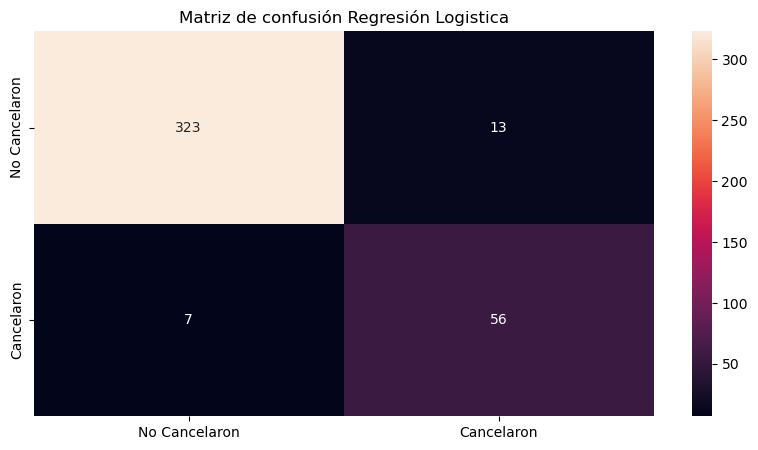

In [57]:
df_cm=pd.DataFrame(confusion_matrix(y_test,predicciones), index=['No Cancelaron','Cancelaron'],
                   columns=['No Cancelaron','Cancelaron'])
plt.figure(figsize=(10,5))
plt.title('Matriz de confusión Regresión Logistica')
sns.heatmap(df_cm,annot=True, fmt='g')
plt.show()
                   

Reporte de Clasificación Detallado
Para una evaluación exhaustiva, generamos el reporte de métricas principales. Mientras que la exactitud mide el total, aquí analizamos:

Precision (Precisión): De todos los que el modelo marcó como "Default", ¿cuántos realmente lo fueron? (Evita molestar a clientes buenos).

Recall (Exhaustividad): De todos los clientes que realmente entraron en default, ¿cuántos logró atrapar el modelo? (Mide la seguridad financiera).

F1-Score: El equilibrio perfecto entre las dos anteriores.

In [58]:
print(classification_report(y_test,predicciones))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       336
           1       0.81      0.89      0.85        63

    accuracy                           0.95       399
   macro avg       0.90      0.93      0.91       399
weighted avg       0.95      0.95      0.95       399



In [ ]:
Análisis de Curva ROC y Capacidad de Discriminación (AUC)
Para finalizar la evaluación, implementamos la Curva ROC (Receiver Operating Characteristic). Esta métrica es fundamental en el scoring crediticio
porque mide la relación entre la tasa de verdaderos positivos y falsos positivos.


In [65]:
#curva ROC
from sklearn.metrics import roc_curve, roc_auc_score

r_probs =[0 for _ in range(len(y_test))]
rl_probs=modelo.predict(X_test)


r_fpr, r_tpr, _= roc_curve(y_test, r_probs)

rl_fpr, rl_tpr, _= roc_curve(y_test, rl_probs)

r_auc=roc_auc_score(y_test, r_probs)
rl_auc=roc_auc_score(y_test, rl_probs)


print('Random (chance) prediction: AUROC= %.3f' % (r_auc))
print('Random logistic regression: AUROC= %.3f' % (rl_auc))


Random (chance) prediction: AUROC= 0.500
Random logistic regression: AUROC= 0.925


Visualización de la Curva ROC
El gráfico de la Curva ROC permite visualizar el equilibrio entre la sensibilidad (capacidad de detectar casos positivos) y la especificidad. El objetivo es que la curva de nuestra Regresión Logística se aproxime lo más posible al ángulo superior izquierdo, lo cual indicaría un modelo con alta tasa de verdaderos positivos y baja tasa de falsos positivos.

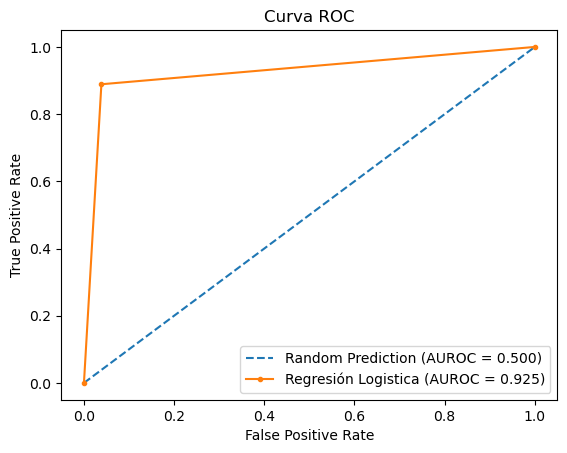

In [66]:
#graficar curva ROC
plt.plot(r_fpr, r_tpr, linestyle='--', label= 'Random Prediction (AUROC = %0.3f)'% r_auc)
plt.plot(rl_fpr, rl_tpr, marker='.', label= 'Regresión Logistica (AUROC = %0.3f)'% rl_auc)


#diseñar grafico
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()
